# Correlation Analysis — Fouling Drivers in CDU Crude Preheat Train

**Purpose:** Identify what drives heat-exchanger fouling (U_relative) using Pearson & Spearman correlations.

**Engineering questions answered:**
1. Does fouling grow predictably with time-on-duty?
2. Which crude properties (API, Asphaltenes, MCRT) drive faster fouling?
3. Do operating conditions (temperature, duty) accelerate deposition?
4. Which HXs foul together vs. independently?
5. How does HX fouling affect furnace duty?

**Input:** `Feature_calculated.csv` (output of `2_Feature_calculation.ipynb`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FEATURE_PATH = r'C:\Desktop\Bangchak Internship 2026\Data\Feature_calculated.csv'
FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\correlation'
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
feature_df = pd.read_csv(FEATURE_PATH, index_col=0, parse_dates=True)
print(f'Loaded: {feature_df.shape[0]} days x {feature_df.shape[1]} columns')
print(f'Date range: {feature_df.index.min().date()} to {feature_df.index.max().date()}')

Loaded: 836 days x 379 columns
Date range: 2024-01-01 to 2026-06-02


In [3]:
# ── Column groups ────────────────────────────────────────────────────────────
HX_LIST = ['E101AB','E101CD','E101EF','E102','E103AB','E104','E105AB',
           'E106AB','E107AB','E108AB','E109AB','E110ABC','E111','E112AB','E112C','E113A']

# Approximate upstream→downstream order in preheat train
HX_ORDER = ['E101AB','E101CD','E101EF','E102',
            'E103AB','E104','E105AB',
            'E106AB','E107AB','E108AB','E109AB',
            'E110ABC','E111','E112AB','E112C','E113A']

CRUDE_COLS    = [c for c in ['API','SG_15_6C','Visc_50C_cSt','Visc_100C_cSt',
                              'MCRT_pct','Asphaltenes_pct'] if c in feature_df.columns]
FURNACE_COLS  = [c for c in ['Q_furnace_kW','excess_air_frac','lambda_excess_air_ratio']
                 if c in feature_df.columns]

UREL_COLS = [f'{h}_U_relative'    for h in HX_LIST if f'{h}_U_relative'    in feature_df.columns]
RF_COLS   = [f'{h}_Rf_run'        for h in HX_LIST if f'{h}_Rf_run'        in feature_df.columns]
DOD_COLS  = [f'{h}_days_on_duty'  for h in HX_LIST if f'{h}_days_on_duty'  in feature_df.columns]
Q_COLS    = [f'{h}_Q'             for h in HX_LIST if f'{h}_Q'             in feature_df.columns]
TAVG_COLS = [f'{h}_Tavg'          for h in HX_LIST if f'{h}_Tavg'          in feature_df.columns]
U_COLS    = [f'{h}_U'             for h in HX_LIST if f'{h}_U'             in feature_df.columns]
EFF_COLS  = [f'{h}_effectiveness' for h in HX_LIST if f'{h}_effectiveness' in feature_df.columns]

print(f'HX with U_relative : {len(UREL_COLS)}/{len(HX_LIST)}')
print(f'Crude properties   : {CRUDE_COLS}')
print(f'Furnace columns    : {FURNACE_COLS}')

HX with U_relative : 16/16
Crude properties   : ['API', 'SG_15_6C', 'Visc_50C_cSt', 'Visc_100C_cSt', 'MCRT_pct', 'Asphaltenes_pct']
Furnace columns    : ['Q_furnace_kW', 'excess_air_frac', 'lambda_excess_air_ratio']


---
## 1. Operating Coverage — Data Availability

Before correlating, verify how many days each HX has valid (operating) U_relative.
NaN = HX offline or below threshold — these rows must be excluded per HX.

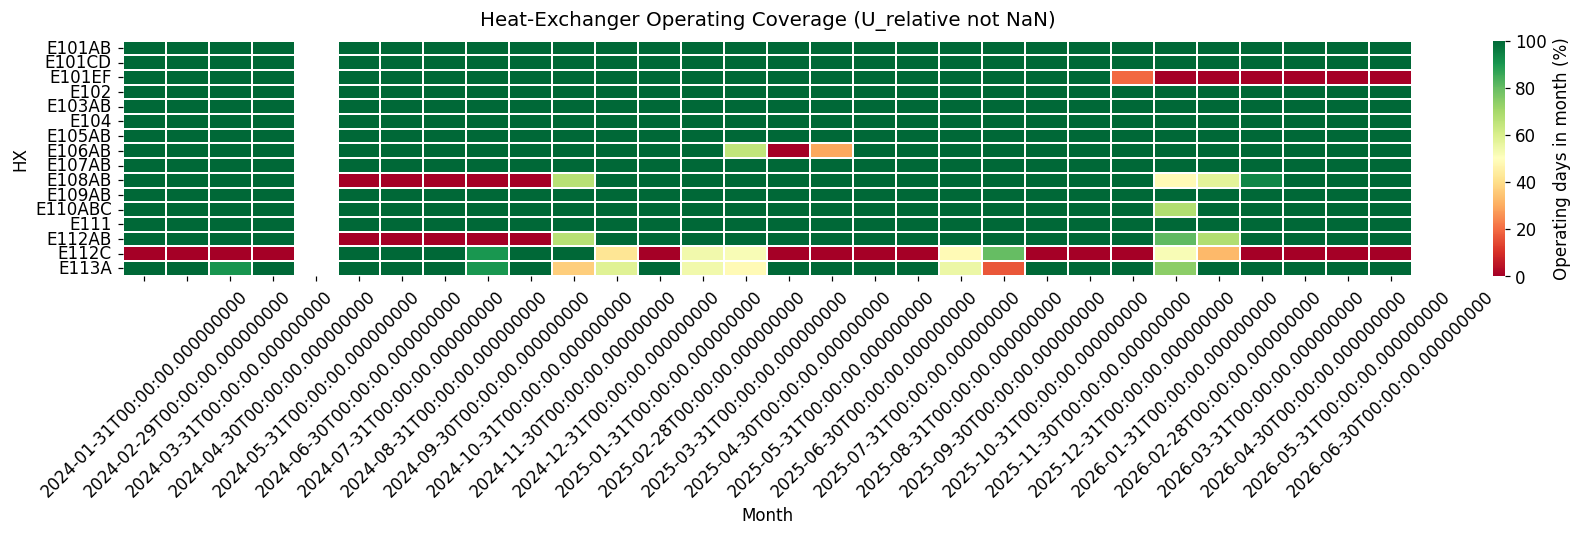


Average operating coverage per HX:
E112C       32.894737
E108AB      78.468900
E101EF      78.708134
E112AB      80.263158
E113A       86.363636
E106AB      92.464115
E110ABC     98.803828
E101CD     100.000000
E105AB     100.000000
E104       100.000000
E103AB     100.000000
E102       100.000000
E101AB     100.000000
E107AB     100.000000
E109AB     100.000000
E111       100.000000


In [4]:
# ── 1. Operating coverage heatmap ────────────────────────────────────────────
monthly_avail = (feature_df[UREL_COLS]
                 .notna()
                 .resample('ME')
                 .mean() * 100)
monthly_avail.columns = [c.replace('_U_relative','') for c in monthly_avail.columns]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(monthly_avail.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, cbar_kws={'label': 'Operating days in month (%)'})
ax.set_title('Heat-Exchanger Operating Coverage (U_relative not NaN)', fontsize=13, pad=10)
ax.set_xlabel('Month')
ax.set_ylabel('HX')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '1_operating_coverage.png'), bbox_inches='tight')
plt.show()

# Summary
avail_pct = feature_df[UREL_COLS].notna().mean() * 100
print('\nAverage operating coverage per HX:')
print(avail_pct.rename(lambda c: c.replace('_U_relative','')).sort_values().to_string())

---
## 2. Fouling vs. Time-on-Duty

**Engineering basis:** Fouling resistance accumulates over time. U_relative should decline
monotonically within each clean run (sawtooth pattern). A strong negative correlation with
`days_on_duty` validates that our run segmentation is correct and fouling is measurable.

- **Pearson r** measures linear decline rate
- **Spearman r** measures monotonic (not necessarily linear) decline — more robust

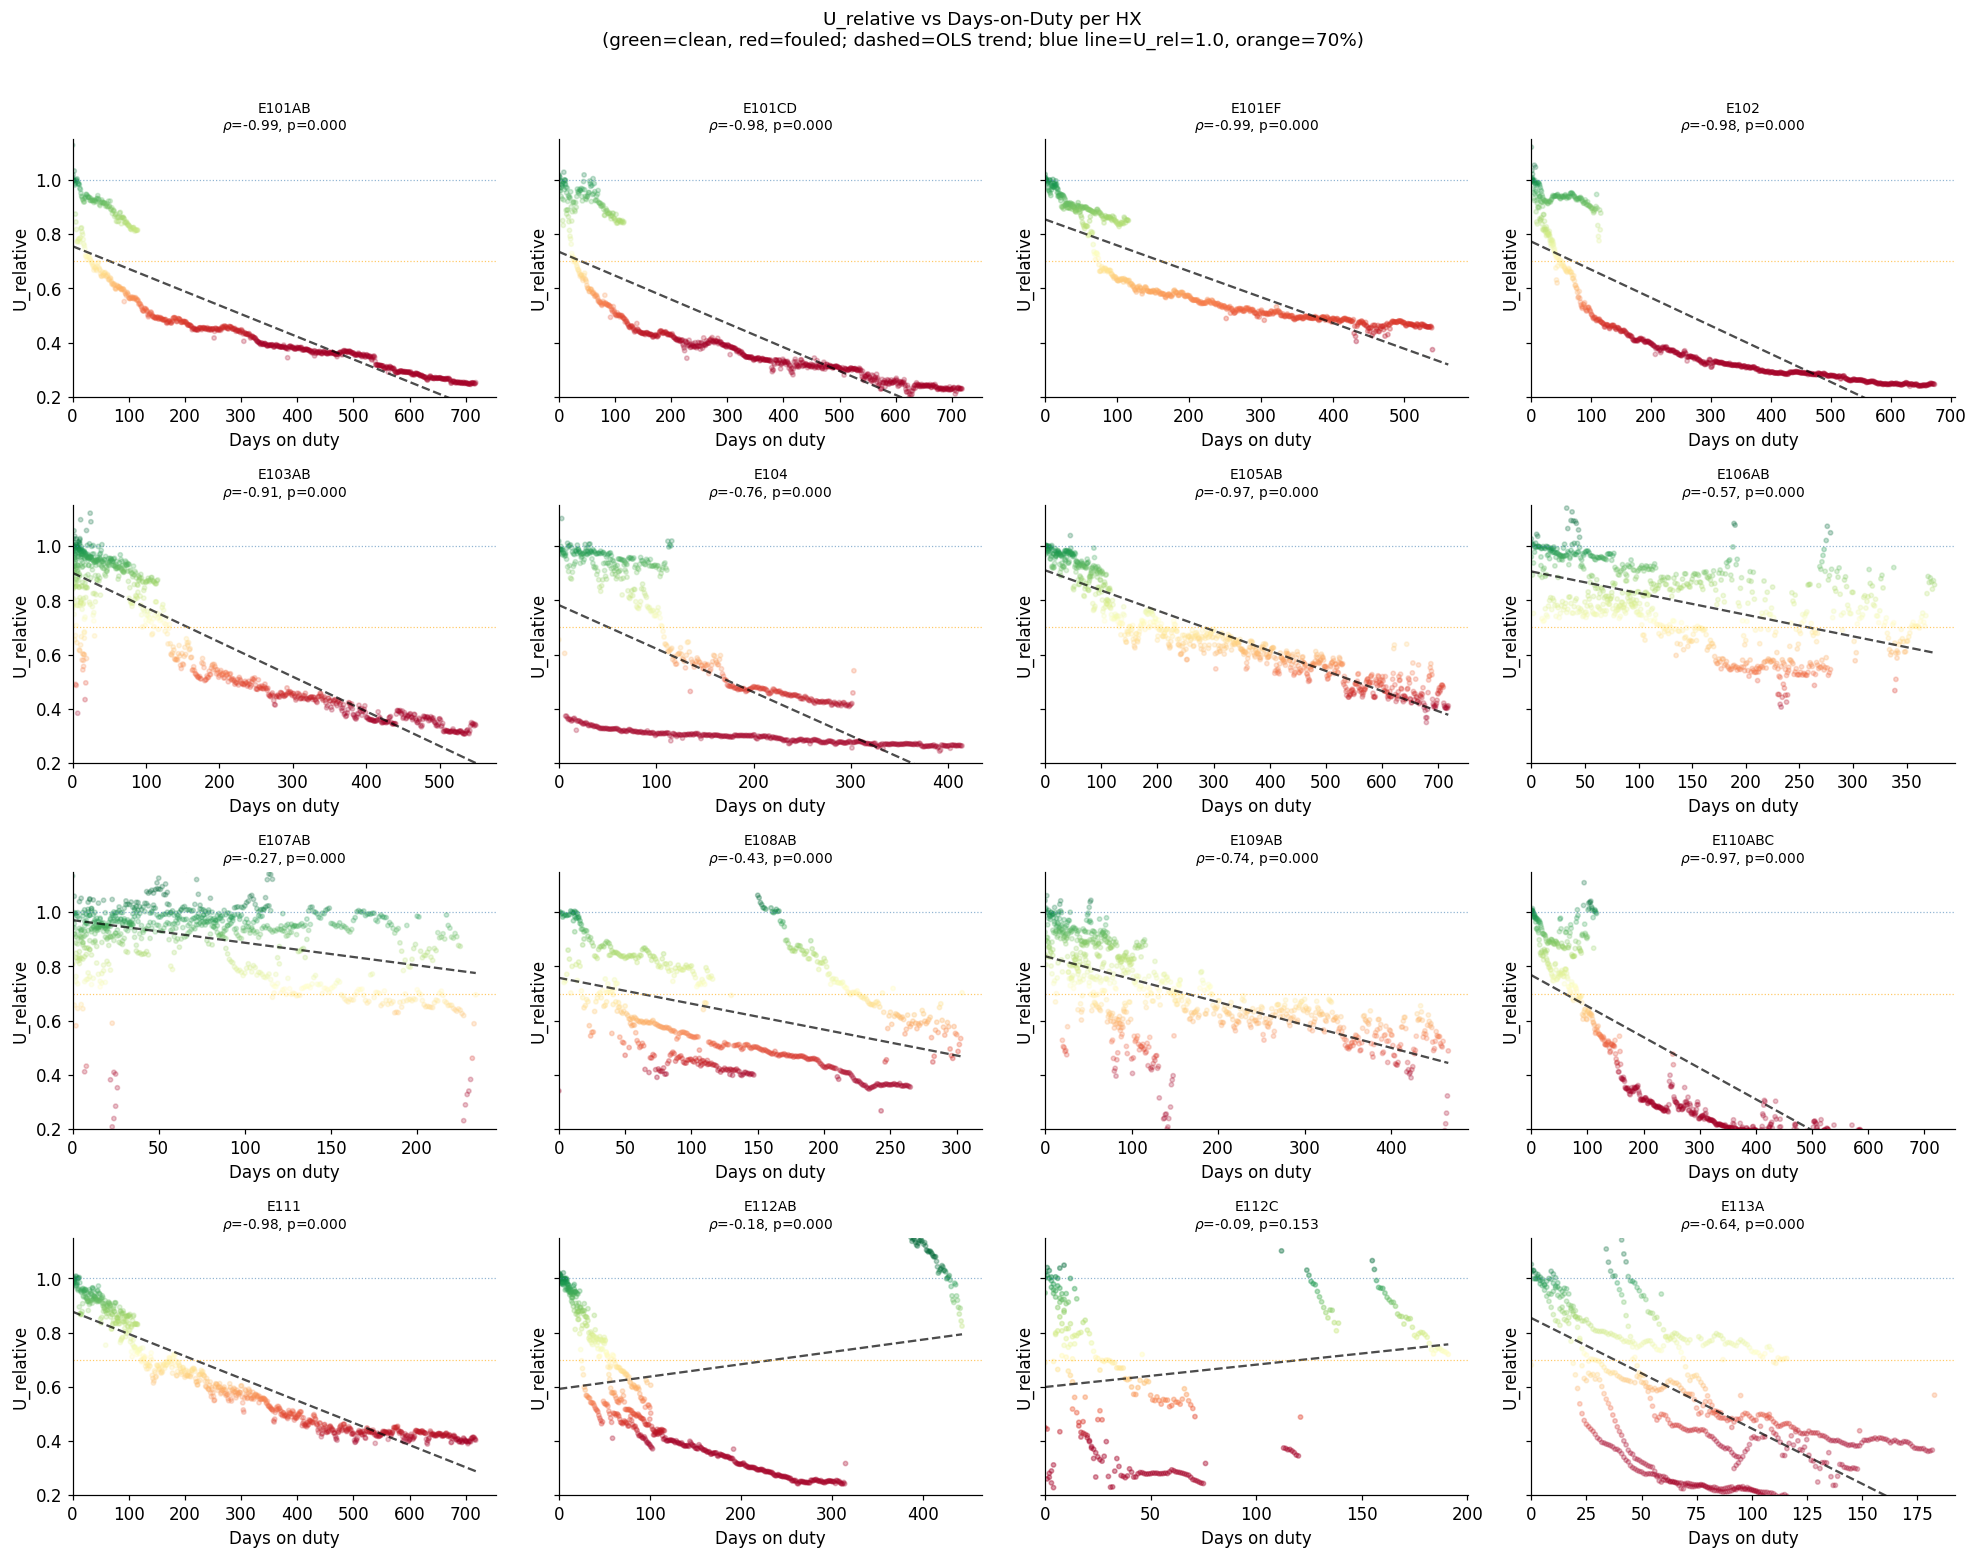

In [5]:
# ── 2a. Scatter: U_relative vs days_on_duty per HX ──────────────────────────
n_cols = 4
n_rows = (len(HX_LIST) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows), sharey=True)
axes = axes.flatten()

corr_dod = {}
for ax, hx in zip(axes, HX_LIST):
    uc = f'{hx}_U_relative'
    dc = f'{hx}_days_on_duty'
    if uc not in feature_df.columns or dc not in feature_df.columns:
        ax.set_visible(False)
        continue

    sub = feature_df[[uc, dc]].dropna()
    if len(sub) < 20:
        ax.text(0.5, 0.5, 'Insufficient\ndata', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(hx)
        continue

    x, y = sub[dc].values, sub[uc].values

    # Spearman correlation (robust to outliers)
    rho, pval = stats.spearmanr(x, y)
    corr_dod[hx] = {'Spearman_r': round(rho, 3), 'p_value': round(pval, 4), 'N': len(sub)}

    # Scatter (alpha for density)
    alpha = max(0.05, min(0.4, 200 / len(sub)))
    c_arr = y  # color by U_relative itself
    sc = ax.scatter(x, y, c=c_arr, cmap='RdYlGn', vmin=0.4, vmax=1.05,
                    alpha=alpha, s=8, rasterized=True)

    # OLS trend line
    slope, intercept, *_ = stats.linregress(x, y)
    xrng = np.array([x.min(), x.max()])
    ax.plot(xrng, slope * xrng + intercept, 'k--', lw=1.5, alpha=0.7)

    ax.set_title(f'{hx}\n$\\rho$={rho:.2f}, p={pval:.3f}', fontsize=9)
    ax.set_xlabel('Days on duty')
    ax.set_ylabel('U_relative')
    ax.set_xlim(left=0)
    ax.set_ylim(0.2, 1.15)
    ax.axhline(1.0, color='steelblue', lw=0.8, ls=':', alpha=0.6)
    ax.axhline(0.7, color='orange', lw=0.8, ls=':', alpha=0.6)

for ax in axes[len(HX_LIST):]:
    ax.set_visible(False)

fig.suptitle('U_relative vs Days-on-Duty per HX\n'
             '(green=clean, red=fouled; dashed=OLS trend; blue line=U_rel=1.0, orange=70%)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2a_urel_vs_dod.png'), bbox_inches='tight')
plt.show()

Spearman rho (U_relative vs days_on_duty):
  Negative = fouling builds with time (expected)

         Spearman_r  p_value      N
E101AB       -0.988   0.0000  836.0
E101EF       -0.988   0.0000  658.0
E101CD       -0.984   0.0000  836.0
E102         -0.981   0.0000  836.0
E111         -0.980   0.0000  836.0
E105AB       -0.970   0.0000  836.0
E110ABC      -0.969   0.0000  826.0
E103AB       -0.906   0.0000  836.0
E104         -0.759   0.0000  836.0
E109AB       -0.743   0.0000  836.0
E113A        -0.638   0.0000  722.0
E106AB       -0.566   0.0000  773.0
E108AB       -0.425   0.0000  656.0
E107AB       -0.271   0.0000  836.0
E112AB       -0.177   0.0000  671.0
E112C        -0.087   0.1525  275.0


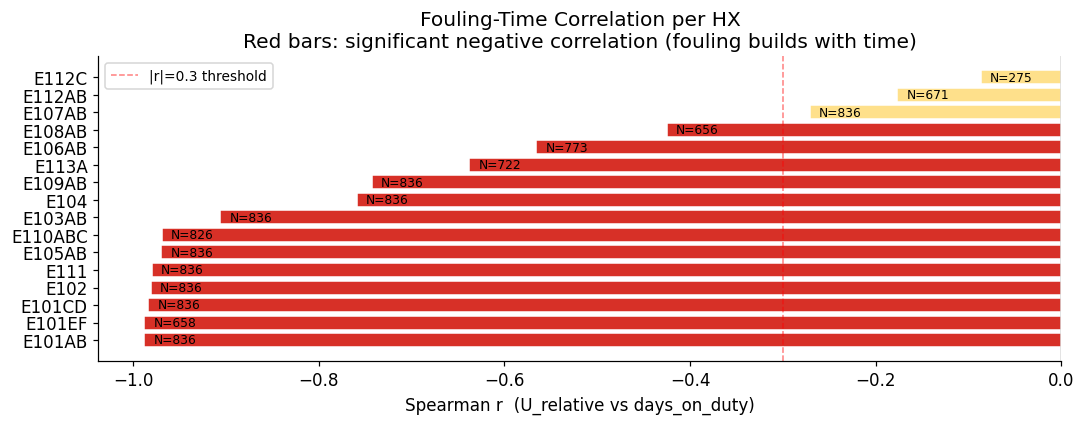

In [6]:
# ── 2b. Spearman correlation summary: U_relative vs days_on_duty ─────────────
if corr_dod:
    dod_df = pd.DataFrame(corr_dod).T.sort_values('Spearman_r')
    print('Spearman rho (U_relative vs days_on_duty):')
    print('  Negative = fouling builds with time (expected)')
    print()
    print(dod_df.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#d73027' if r < -0.3 else '#fee08b' if r < 0 else '#91cf60'
              for r in dod_df['Spearman_r']]
    bars = ax.barh(dod_df.index, dod_df['Spearman_r'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline(-0.3, color='red', lw=1, ls='--', alpha=0.5, label='|r|=0.3 threshold')
    ax.set_xlabel('Spearman r  (U_relative vs days_on_duty)')
    ax.set_title('Fouling-Time Correlation per HX\n'
                 'Red bars: significant negative correlation (fouling builds with time)')
    ax.legend(fontsize=9)
    for bar, (_, row) in zip(bars, dod_df.iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"N={int(row['N'])}", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '2b_spearman_dod.png'), bbox_inches='tight')
    plt.show()

---
## 3. Crude Quality Impact on Fouling

**Engineering basis:** In crude preheat trains, fouling is strongly linked to:
- **Asphaltenes (wt%)** — colloidal aggregates that deposit when destabilised by mixing or temperature
- **MCRT (wt%)** — carbon residue; proxy for coking tendency at elevated temperatures
- **Viscosity** — higher viscosity reduces turbulence (lower Re), thicker laminar sub-layer = more deposition
- **API gravity** — heavy crudes (low API) carry more fouling precursors

We correlate monthly-averaged crude properties against monthly-averaged U_relative per HX.

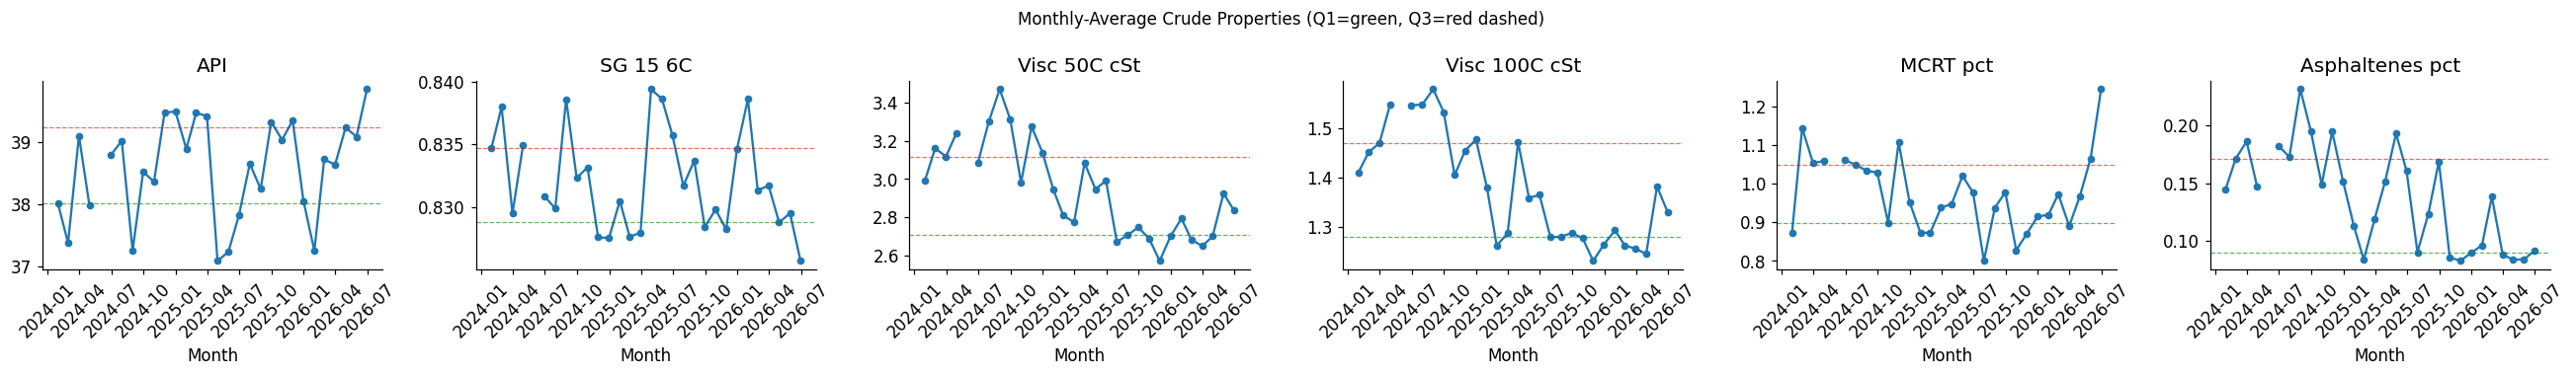

In [7]:
# ── 3a. Monthly average crude properties ─────────────────────────────────────
monthly = feature_df[CRUDE_COLS + UREL_COLS].resample('ME').mean()

if CRUDE_COLS:
    fig, axes = plt.subplots(1, len(CRUDE_COLS), figsize=(4 * len(CRUDE_COLS), 3.5))
    if len(CRUDE_COLS) == 1:
        axes = [axes]
    for ax, col in zip(axes, CRUDE_COLS):
        ax.plot(monthly.index, monthly[col], 'o-', ms=4, lw=1.5)
        ax.set_title(col.replace('_',' '))
        ax.set_xlabel('Month')
        ax.tick_params(axis='x', rotation=45)
        # Mark percentiles
        ax.axhline(monthly[col].quantile(0.25), color='green', ls='--', lw=0.8, alpha=0.6)
        ax.axhline(monthly[col].quantile(0.75), color='red', ls='--', lw=0.8, alpha=0.6)
    fig.suptitle('Monthly-Average Crude Properties (Q1=green, Q3=red dashed)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '3a_crude_timeseries.png'), bbox_inches='tight')
    plt.show()
else:
    print('No crude property columns found.')

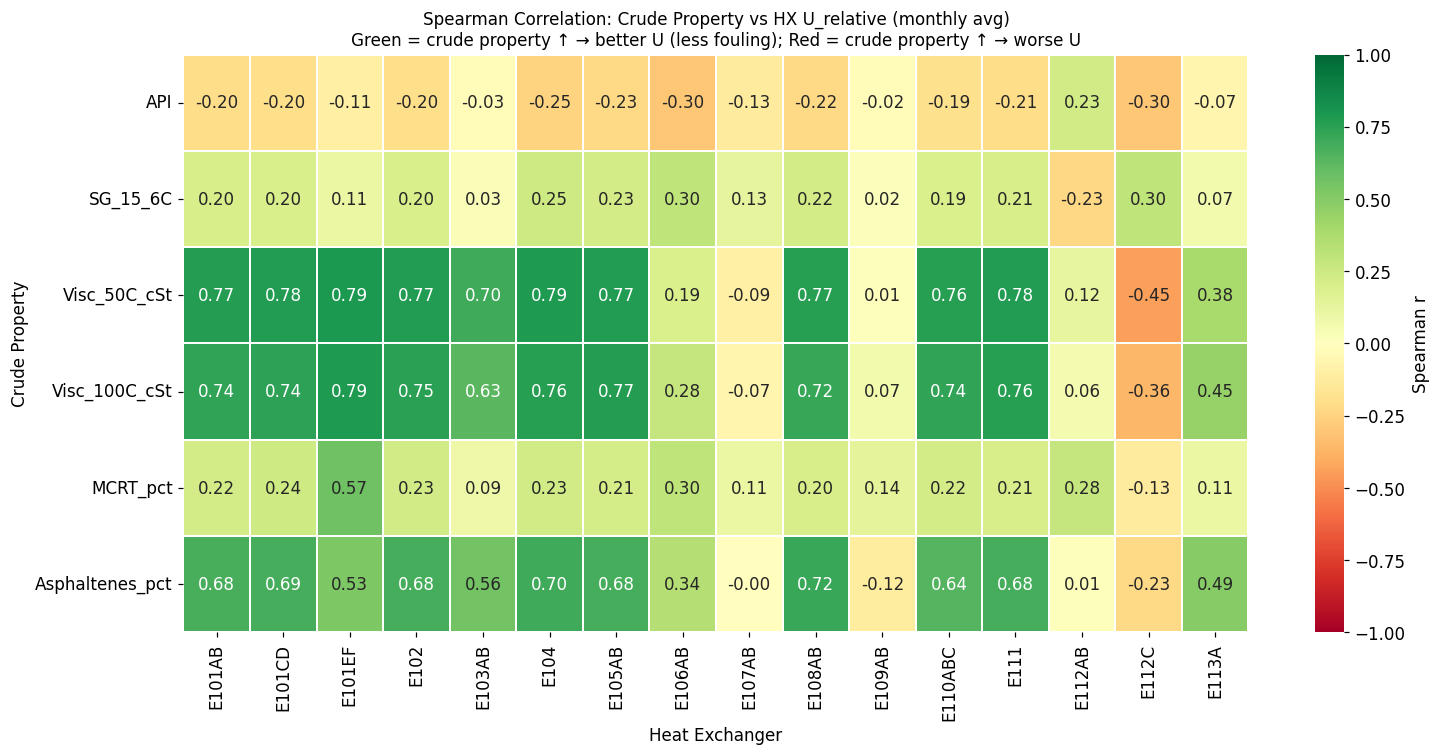


Engineering interpretation:
  API ↑ (lighter crude)  → expect U_relative ↑ (less fouling) → positive r
  Asphaltenes ↑          → expect U_relative ↓ (more fouling) → negative r
  MCRT ↑                 → expect U_relative ↓ (coking risk)  → negative r
  Viscosity ↑            → lower Re → more deposition          → negative r


In [8]:
# ── 3b. Correlation heatmap: crude properties vs U_relative per HX ───────────
if CRUDE_COLS:
    corr_matrix = pd.DataFrame(index=CRUDE_COLS,
                                columns=[c.replace('_U_relative','') for c in UREL_COLS],
                                dtype=float)
    for cp in CRUDE_COLS:
        for uc in UREL_COLS:
            sub = monthly[[cp, uc]].dropna()
            if len(sub) >= 6:
                r, _ = stats.spearmanr(sub[cp], sub[uc])
                corr_matrix.loc[cp, uc.replace('_U_relative','')] = round(r, 3)

    fig, ax = plt.subplots(figsize=(14, len(CRUDE_COLS) + 1))
    mask = corr_matrix.isna()
    sns.heatmap(corr_matrix.astype(float), ax=ax, cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.3,
                mask=mask, cbar_kws={'label': 'Spearman r'})
    ax.set_title('Spearman Correlation: Crude Property vs HX U_relative (monthly avg)\n'
                 'Green = crude property ↑ → better U (less fouling); Red = crude property ↑ → worse U',
                 fontsize=11)
    ax.set_xlabel('Heat Exchanger')
    ax.set_ylabel('Crude Property')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '3b_crude_urel_heatmap.png'), bbox_inches='tight')
    plt.show()

    print('\nEngineering interpretation:')
    print('  API ↑ (lighter crude)  → expect U_relative ↑ (less fouling) → positive r')
    print('  Asphaltenes ↑          → expect U_relative ↓ (more fouling) → negative r')
    print('  MCRT ↑                 → expect U_relative ↓ (coking risk)  → negative r')
    print('  Viscosity ↑            → lower Re → more deposition          → negative r')

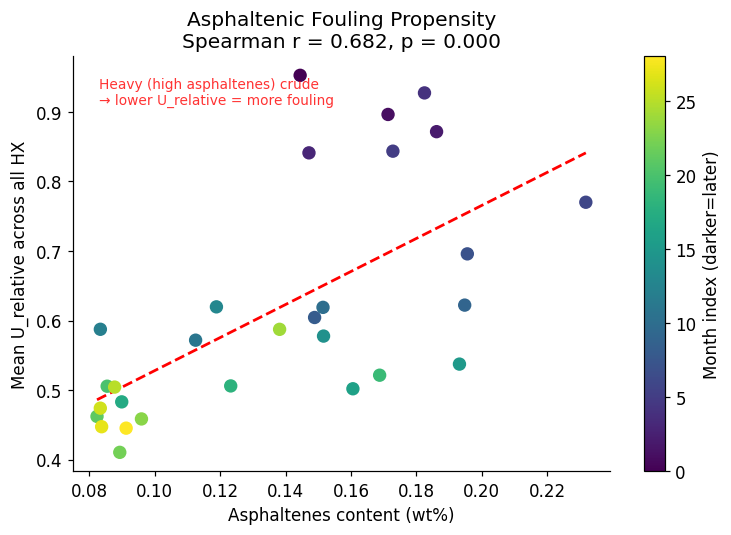

In [9]:
# ── 3c. Key scatter: Asphaltenes vs mean U_relative (monthly) ────────────────
if 'Asphaltenes_pct' in CRUDE_COLS:
    mean_urel = monthly[UREL_COLS].mean(axis=1)
    sub = pd.DataFrame({'Asphaltenes_pct': monthly['Asphaltenes_pct'],
                        'Mean_U_relative': mean_urel}).dropna()

    if len(sub) >= 6:
        rho, pval = stats.spearmanr(sub['Asphaltenes_pct'], sub['Mean_U_relative'])
        fig, ax = plt.subplots(figsize=(7, 5))
        sc = ax.scatter(sub['Asphaltenes_pct'], sub['Mean_U_relative'],
                        c=range(len(sub)), cmap='viridis', s=60, zorder=3)
        plt.colorbar(sc, ax=ax, label='Month index (darker=later)')

        slope, intercept, *_ = stats.linregress(sub['Asphaltenes_pct'], sub['Mean_U_relative'])
        x_line = np.linspace(sub['Asphaltenes_pct'].min(), sub['Asphaltenes_pct'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'r--', lw=1.8)

        ax.set_xlabel('Asphaltenes content (wt%)')
        ax.set_ylabel('Mean U_relative across all HX')
        ax.set_title(f'Asphaltenic Fouling Propensity\n'
                     f'Spearman r = {rho:.3f}, p = {pval:.3f}')
        ax.text(0.05, 0.95, 'Heavy (high asphaltenes) crude\n→ lower U_relative = more fouling',
                transform=ax.transAxes, va='top', fontsize=9, color='red', alpha=0.8)
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, '3c_asphaltenes_scatter.png'), bbox_inches='tight')
        plt.show()

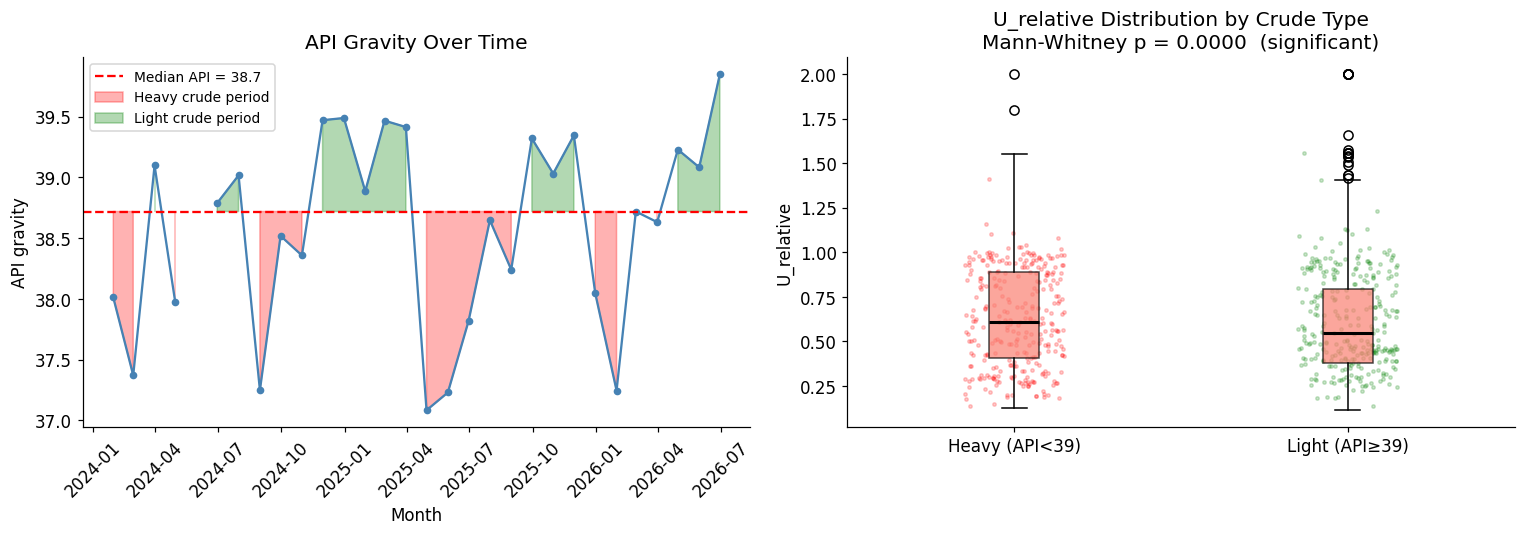

In [10]:
# ── 3d. API gravity boxplot: Heavy vs Light crude periods ─────────────────────
if 'API' in CRUDE_COLS:
    api_monthly = monthly['API'].dropna()
    api_median  = api_monthly.median()
    heavy_mask  = feature_df['API'] < api_median

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: API time series with split
    axes[0].plot(monthly.index, monthly['API'], 'o-', ms=4, lw=1.5, color='steelblue')
    axes[0].axhline(api_median, color='red', ls='--', lw=1.5,
                    label=f'Median API = {api_median:.1f}')
    axes[0].fill_between(monthly.index, monthly['API'], api_median,
                         where=monthly['API'] < api_median,
                         alpha=0.3, color='red', label='Heavy crude period')
    axes[0].fill_between(monthly.index, monthly['API'], api_median,
                         where=monthly['API'] >= api_median,
                         alpha=0.3, color='green', label='Light crude period')
    axes[0].set_title('API Gravity Over Time')
    axes[0].set_xlabel('Month'); axes[0].set_ylabel('API gravity')
    axes[0].legend(fontsize=9); axes[0].tick_params(axis='x', rotation=45)

    # Right: U_relative distribution: heavy vs light
    urel_all = feature_df[UREL_COLS].stack().reset_index()
    urel_all.columns = ['Date','HX_col','U_relative']
    urel_all['API'] = urel_all['Date'].map(feature_df['API'])
    urel_all['Crude_type'] = urel_all['API'].apply(
        lambda x: f'Heavy (API<{api_median:.0f})' if x < api_median
                  else f'Light (API≥{api_median:.0f})')
    urel_all = urel_all.dropna(subset=['U_relative','API'])

    axes[1].boxplot(
        [urel_all.loc[urel_all['Crude_type'].str.startswith('Heavy'), 'U_relative'],
         urel_all.loc[urel_all['Crude_type'].str.startswith('Light'), 'U_relative']],
        labels=[f'Heavy (API<{api_median:.0f})', f'Light (API≥{api_median:.0f})'],
        patch_artist=True,
        boxprops=dict(facecolor='salmon', alpha=0.7),
        medianprops=dict(color='black', lw=2)
    )
    # Overlay scatter
    for i, ctype in enumerate([f'Heavy (API<{api_median:.0f})', f'Light (API≥{api_median:.0f})']):
        sub_type = urel_all[urel_all['Crude_type'] == ctype]['U_relative']
        jitter = np.random.uniform(-0.15, 0.15, min(len(sub_type), 300))
        sample = sub_type.sample(min(len(sub_type), 300), random_state=42)
        axes[1].scatter(i + 1 + jitter, sample, alpha=0.2, s=5,
                        color='red' if i == 0 else 'green')

    # Mann-Whitney U test
    heavy_u = urel_all.loc[urel_all['Crude_type'].str.startswith('Heavy'), 'U_relative']
    light_u = urel_all.loc[urel_all['Crude_type'].str.startswith('Light'), 'U_relative']
    if len(heavy_u) > 10 and len(light_u) > 10:
        stat, pval = stats.mannwhitneyu(heavy_u, light_u, alternative='two-sided')
        axes[1].set_title(f'U_relative Distribution by Crude Type\n'
                          f'Mann-Whitney p = {pval:.4f}  '
                          f'({"significant" if pval < 0.05 else "not significant"})')
    axes[1].set_ylabel('U_relative')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '3d_api_urel_boxplot.png'), bbox_inches='tight')
    plt.show()

---
## 4. Operating Conditions vs. Fouling

**Engineering basis:**
- **Temperature** drives deposition kinetics (Arrhenius-type). Hotter HXs (near furnace) typically foul faster per unit time.
- **Heat duty (Q)** — high Q means large crude-side ΔT, which can increase wall temperature and accelerate deposition.
- **Crude flow** — higher velocity = higher Re = thinner viscous sub-layer = less deposition (velocity effect).

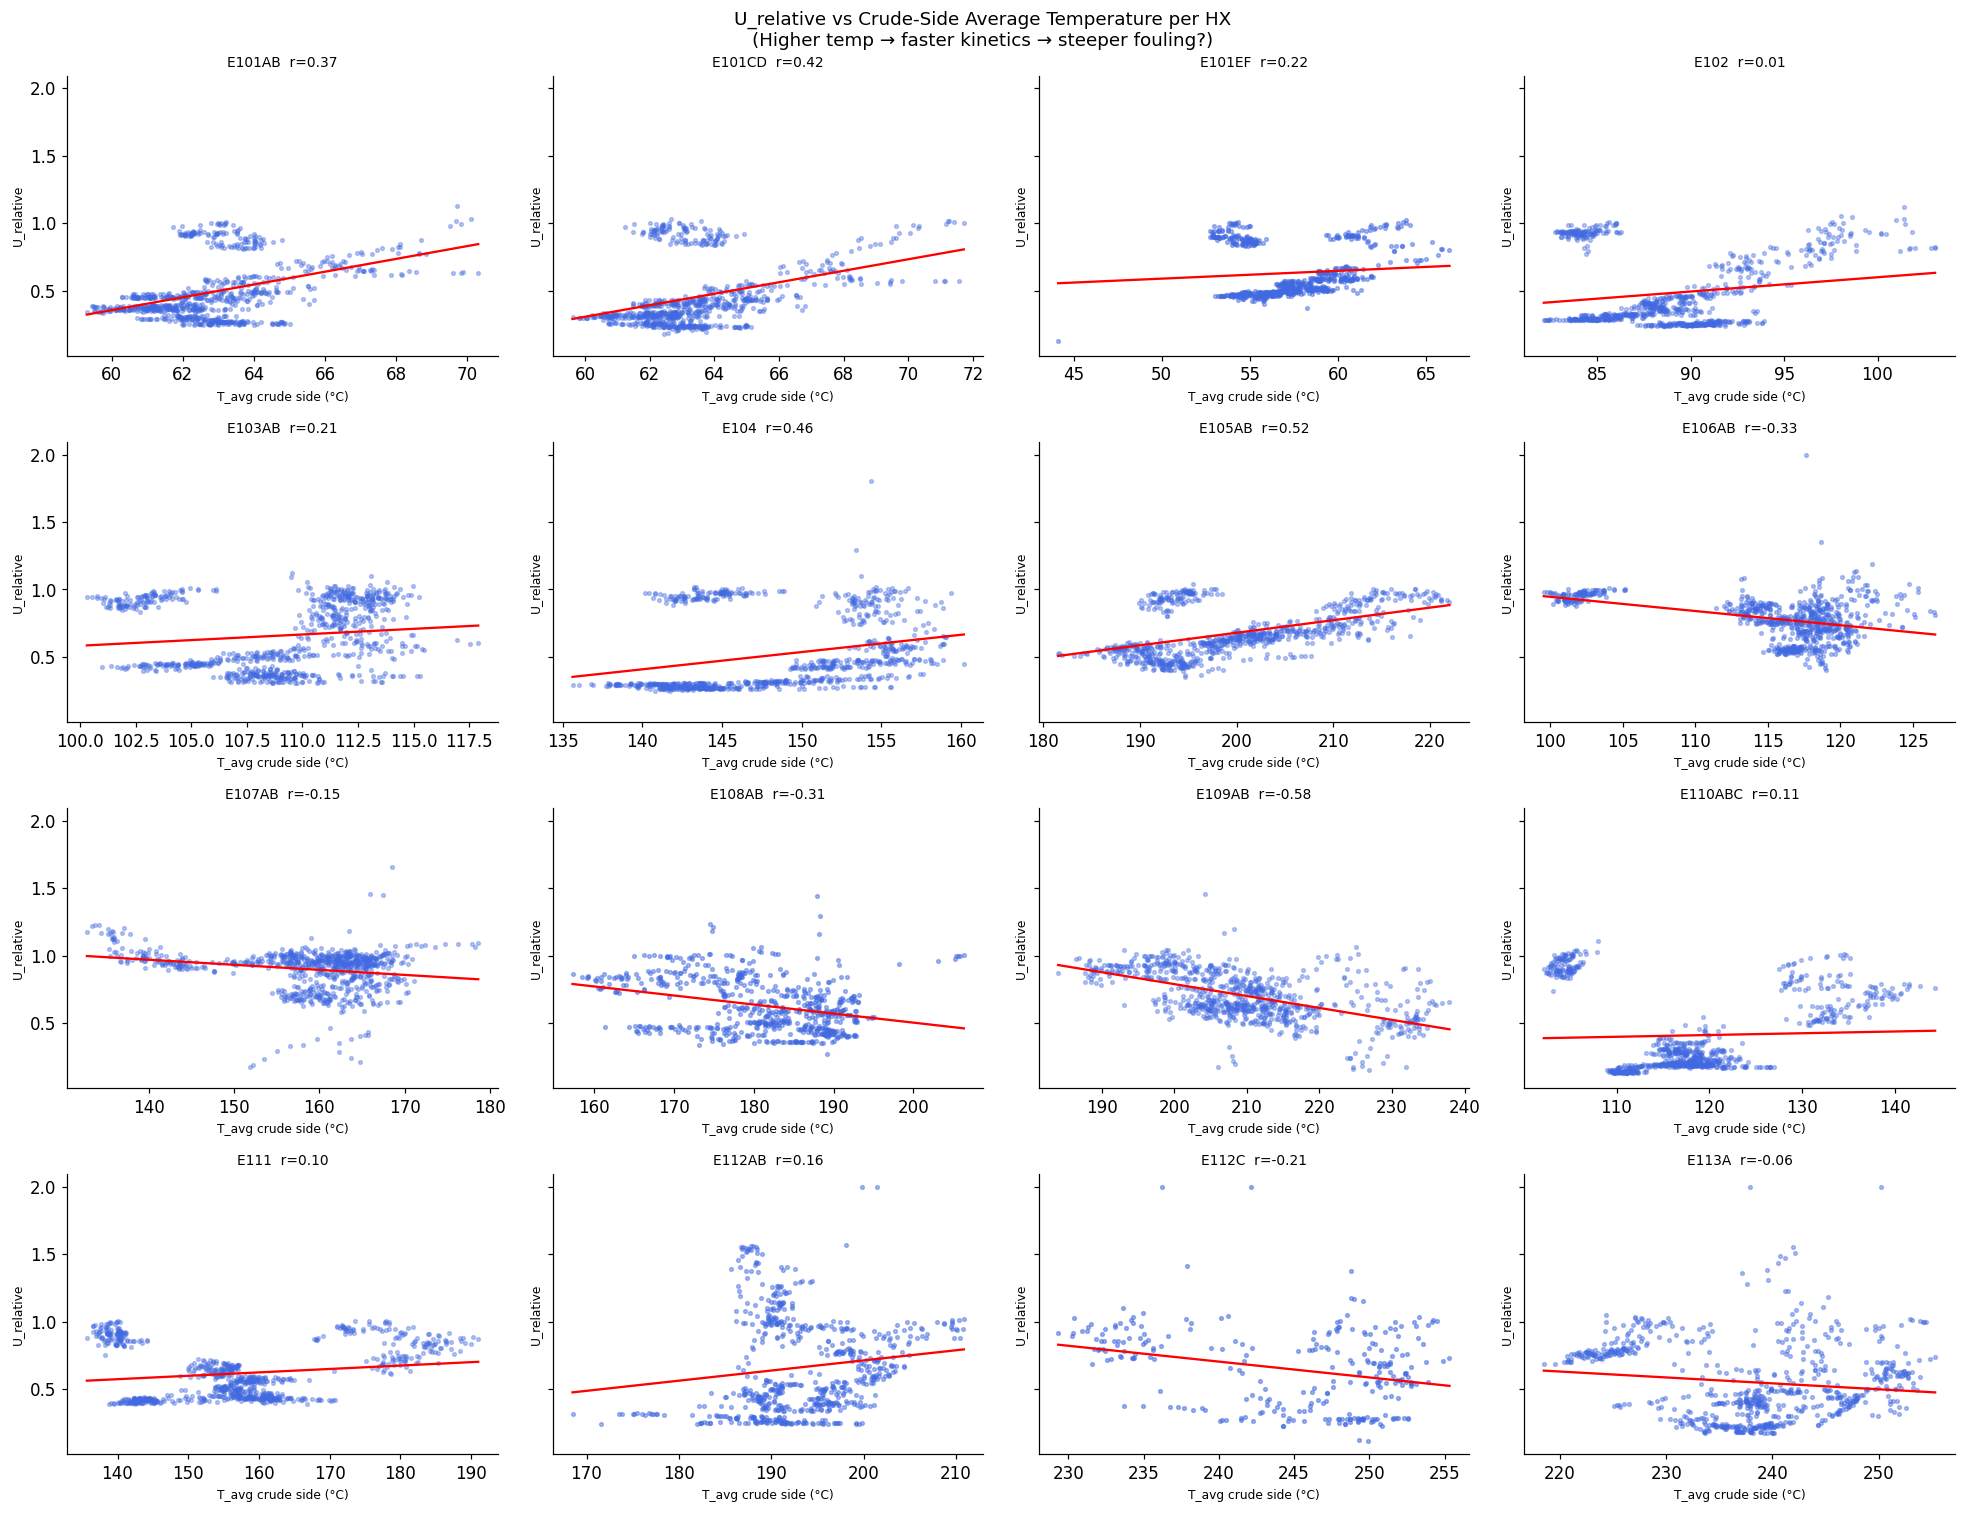

In [11]:
# ── 4a. Tavg vs U_relative: scatter per HX ────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharey=True)
axes = axes.flatten()

temp_corr = {}
for ax, hx in zip(axes, HX_LIST):
    tc = f'{hx}_Tavg'
    uc = f'{hx}_U_relative'
    if tc not in feature_df.columns or uc not in feature_df.columns:
        ax.set_visible(False); continue

    sub = feature_df[[tc, uc]].dropna()
    if len(sub) < 20:
        ax.set_visible(False); continue

    x, y = sub[tc].values, sub[uc].values
    rho, pval = stats.spearmanr(x, y)
    temp_corr[hx] = {'Spearman_r': round(rho,3), 'p': round(pval,4)}

    alpha = max(0.05, min(0.5, 300/len(sub)))
    ax.scatter(x, y, alpha=alpha, s=6, c='royalblue', rasterized=True)
    slope, intercept, *_ = stats.linregress(x, y)
    xr = np.array([x.min(), x.max()])
    ax.plot(xr, slope*xr+intercept, 'r-', lw=1.5)
    ax.set_title(f'{hx}  r={rho:.2f}', fontsize=9)
    ax.set_xlabel('T_avg crude side (°C)', fontsize=8)
    ax.set_ylabel('U_relative', fontsize=8)

for ax in axes[len(HX_LIST):]:
    ax.set_visible(False)

fig.suptitle('U_relative vs Crude-Side Average Temperature per HX\n'
             '(Higher temp → faster kinetics → steeper fouling?)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '4a_temp_vs_urel.png'), bbox_inches='tight')
plt.show()

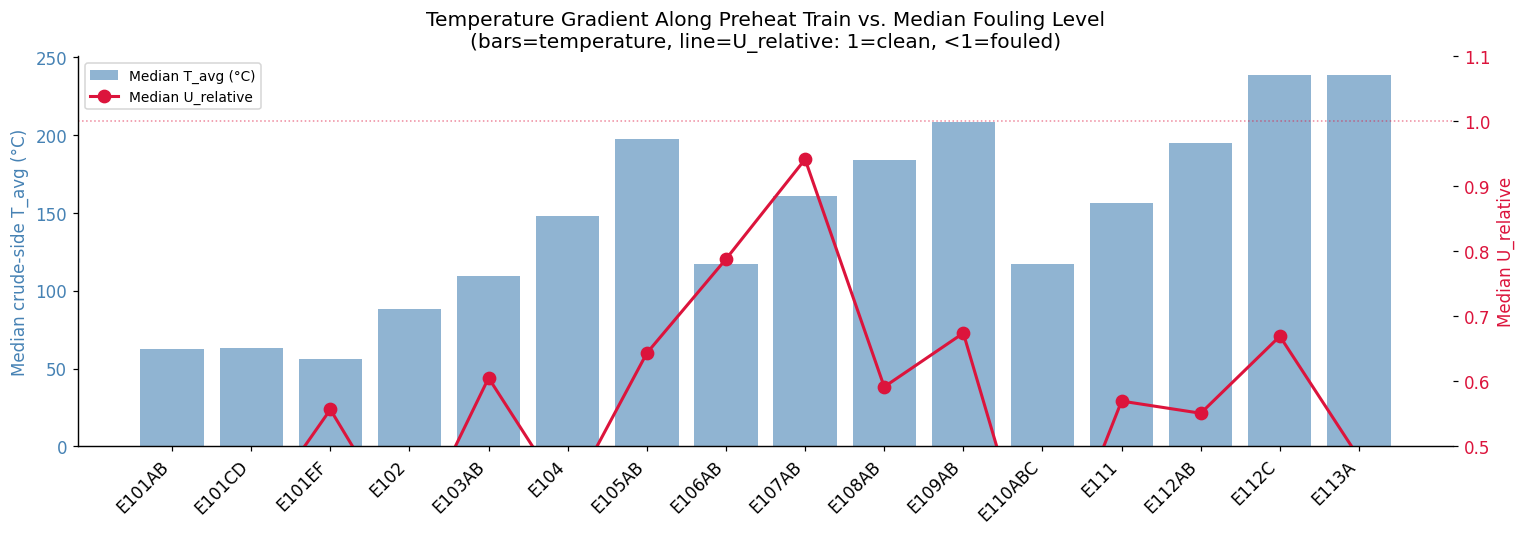

In [12]:
# ── 4b. Temperature gradient across train: mean Tavg per HX ──────────────────
mean_tavg = {hx: feature_df[f'{hx}_Tavg'].median()
             for hx in HX_LIST if f'{hx}_Tavg' in feature_df.columns}
mean_urel  = {hx: feature_df[f'{hx}_U_relative'].median()
              for hx in HX_LIST if f'{hx}_U_relative' in feature_df.columns}

hx_both = [hx for hx in HX_ORDER if hx in mean_tavg and hx in mean_urel]
tavg_vals = [mean_tavg[h] for h in hx_both]
urel_vals = [mean_urel[h] for h in hx_both]

fig, ax1 = plt.subplots(figsize=(14, 5))
color1 = 'steelblue'
ax1.bar(range(len(hx_both)), tavg_vals, color=color1, alpha=0.6, label='Median T_avg (°C)')
ax1.set_xticks(range(len(hx_both)))
ax1.set_xticklabels(hx_both, rotation=45, ha='right')
ax1.set_ylabel('Median crude-side T_avg (°C)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('Temperature Gradient Along Preheat Train vs. Median Fouling Level\n'
              '(bars=temperature, line=U_relative: 1=clean, <1=fouled)')

ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(range(len(hx_both)), urel_vals, 'o-', color=color2, ms=8, lw=2,
         label='Median U_relative')
ax2.axhline(1.0, color=color2, ls=':', lw=1, alpha=0.5)
ax2.set_ylabel('Median U_relative', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.5, 1.1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '4b_temp_gradient_train.png'), bbox_inches='tight')
plt.show()

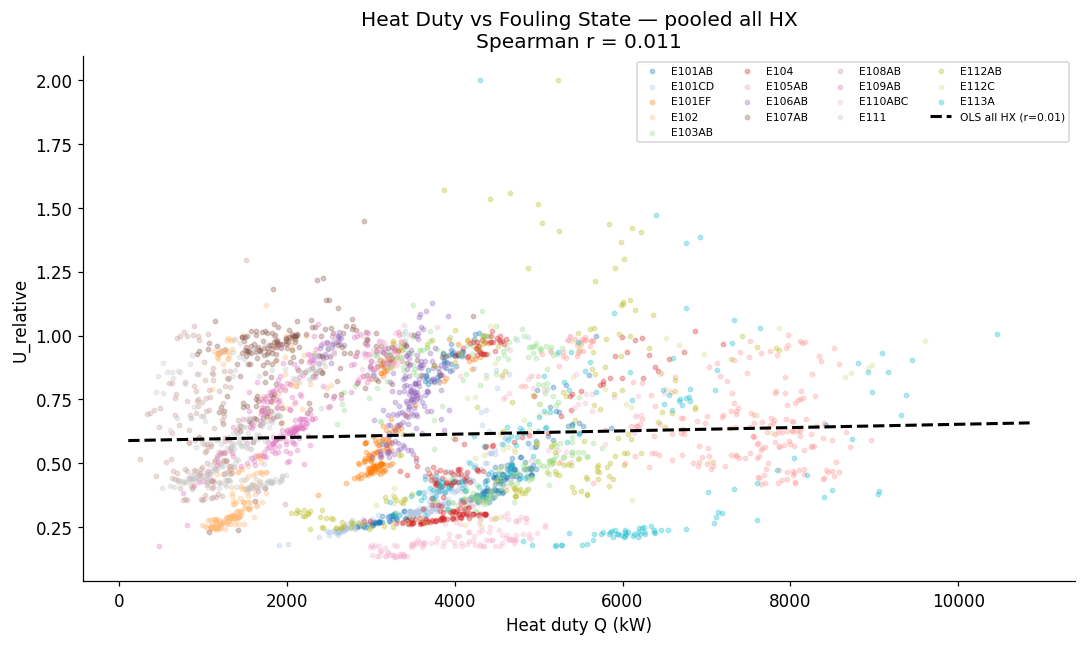

In [13]:
# ── 4c. Duty (Q) vs U_relative: cross-HX pooled ──────────────────────────────
q_urel_rows = []
for hx in HX_LIST:
    qc = f'{hx}_Q'
    uc = f'{hx}_U_relative'
    if qc in feature_df.columns and uc in feature_df.columns:
        sub = feature_df[[qc, uc]].dropna()
        sub['HX'] = hx
        q_urel_rows.append(sub.rename(columns={qc:'Q_kW', uc:'U_relative'}))

if q_urel_rows:
    pool = pd.concat(q_urel_rows)
    # Sample to avoid overplotting
    sample = pool.sample(min(len(pool), 3000), random_state=42)
    hx_colors = {hx: plt.cm.tab20(i/len(HX_LIST)) for i, hx in enumerate(HX_LIST)}

    fig, ax = plt.subplots(figsize=(10, 6))
    for hx_name, grp in sample.groupby('HX'):
        ax.scatter(grp['Q_kW'], grp['U_relative'], alpha=0.3, s=8,
                   color=hx_colors.get(hx_name, 'gray'), label=hx_name, rasterized=True)

    # Overall OLS
    rho, pval = stats.spearmanr(pool['Q_kW'], pool['U_relative'])
    slope, intercept, *_ = stats.linregress(pool['Q_kW'].values, pool['U_relative'].values)
    xr = np.array([pool['Q_kW'].min(), pool['Q_kW'].max()])
    ax.plot(xr, slope*xr+intercept, 'k--', lw=2, label=f'OLS all HX (r={rho:.2f})')

    ax.set_xlabel('Heat duty Q (kW)')
    ax.set_ylabel('U_relative')
    ax.set_title(f'Heat Duty vs Fouling State — pooled all HX\nSpearman r = {rho:.3f}')
    ax.legend(fontsize=7, ncol=4, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '4c_duty_vs_urel.png'), bbox_inches='tight')
    plt.show()

---
## 5. Cross-HX Fouling Correlation

**Engineering question:** When one HX fouls, do others foul simultaneously?

- **High cross-correlation** (r > 0.6) between all HXs → fouling driven by **plant-wide** factor (crude quality, throughput)
- **Low cross-correlation** → fouling is **local** to each HX (temperature, flow, mechanical)

The correlation matrix of U_relative across all 16 HX reveals cluster structure.

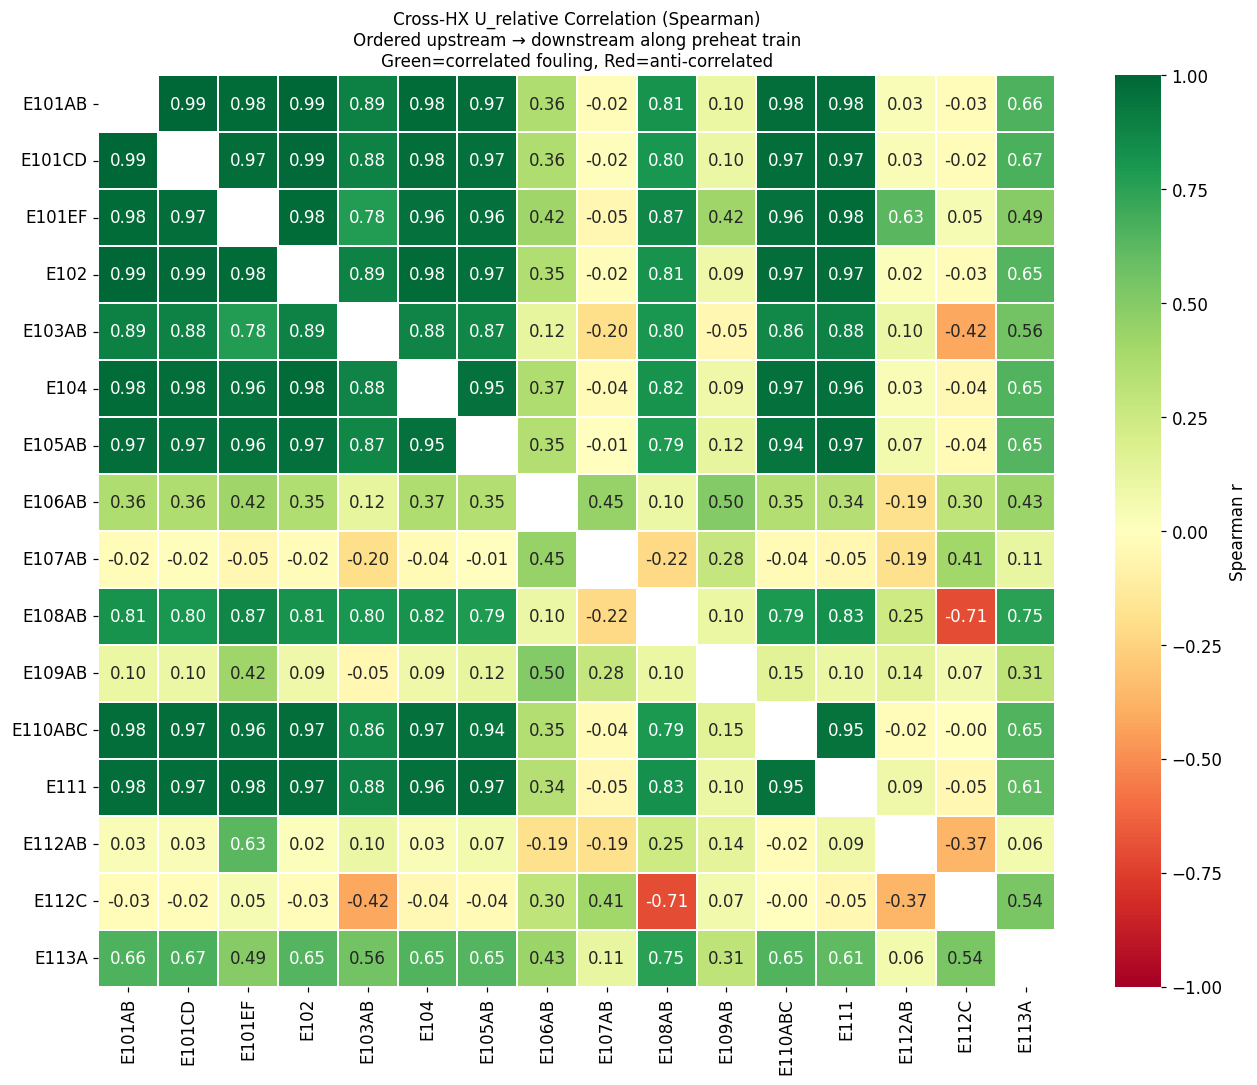

Cross-HX correlation summary:
  Mean  : 0.452
  Median: 0.425
  Pairs with |r| > 0.5: 116 / 240
  Pairs with |r| > 0.3: 150 / 240


In [14]:
# ── 5a. Cross-HX U_relative correlation matrix ───────────────────────────────
urel_daily = feature_df[UREL_COLS].copy()
urel_daily.columns = [c.replace('_U_relative','') for c in urel_daily.columns]

# Reorder by train position
ordered_cols = [h for h in HX_ORDER if h in urel_daily.columns]
urel_ordered = urel_daily[ordered_cols]

corr_cross = urel_ordered.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(corr_cross), dtype=bool)
sns.heatmap(corr_cross, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3, mask=mask,
            cbar_kws={'label': 'Spearman r'})
ax.set_title('Cross-HX U_relative Correlation (Spearman)\n'
             'Ordered upstream → downstream along preheat train\n'
             'Green=correlated fouling, Red=anti-correlated', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '5a_cross_hx_corr.png'), bbox_inches='tight')
plt.show()

# Summary stats
upper = corr_cross.where(~mask & (corr_cross.notna()))
upper_vals = upper.stack()
print(f'Cross-HX correlation summary:')
print(f'  Mean  : {upper_vals.mean():.3f}')
print(f'  Median: {upper_vals.median():.3f}')
print(f'  Pairs with |r| > 0.5: {(upper_vals.abs() > 0.5).sum()} / {len(upper_vals)}')
print(f'  Pairs with |r| > 0.3: {(upper_vals.abs() > 0.3).sum()} / {len(upper_vals)}')

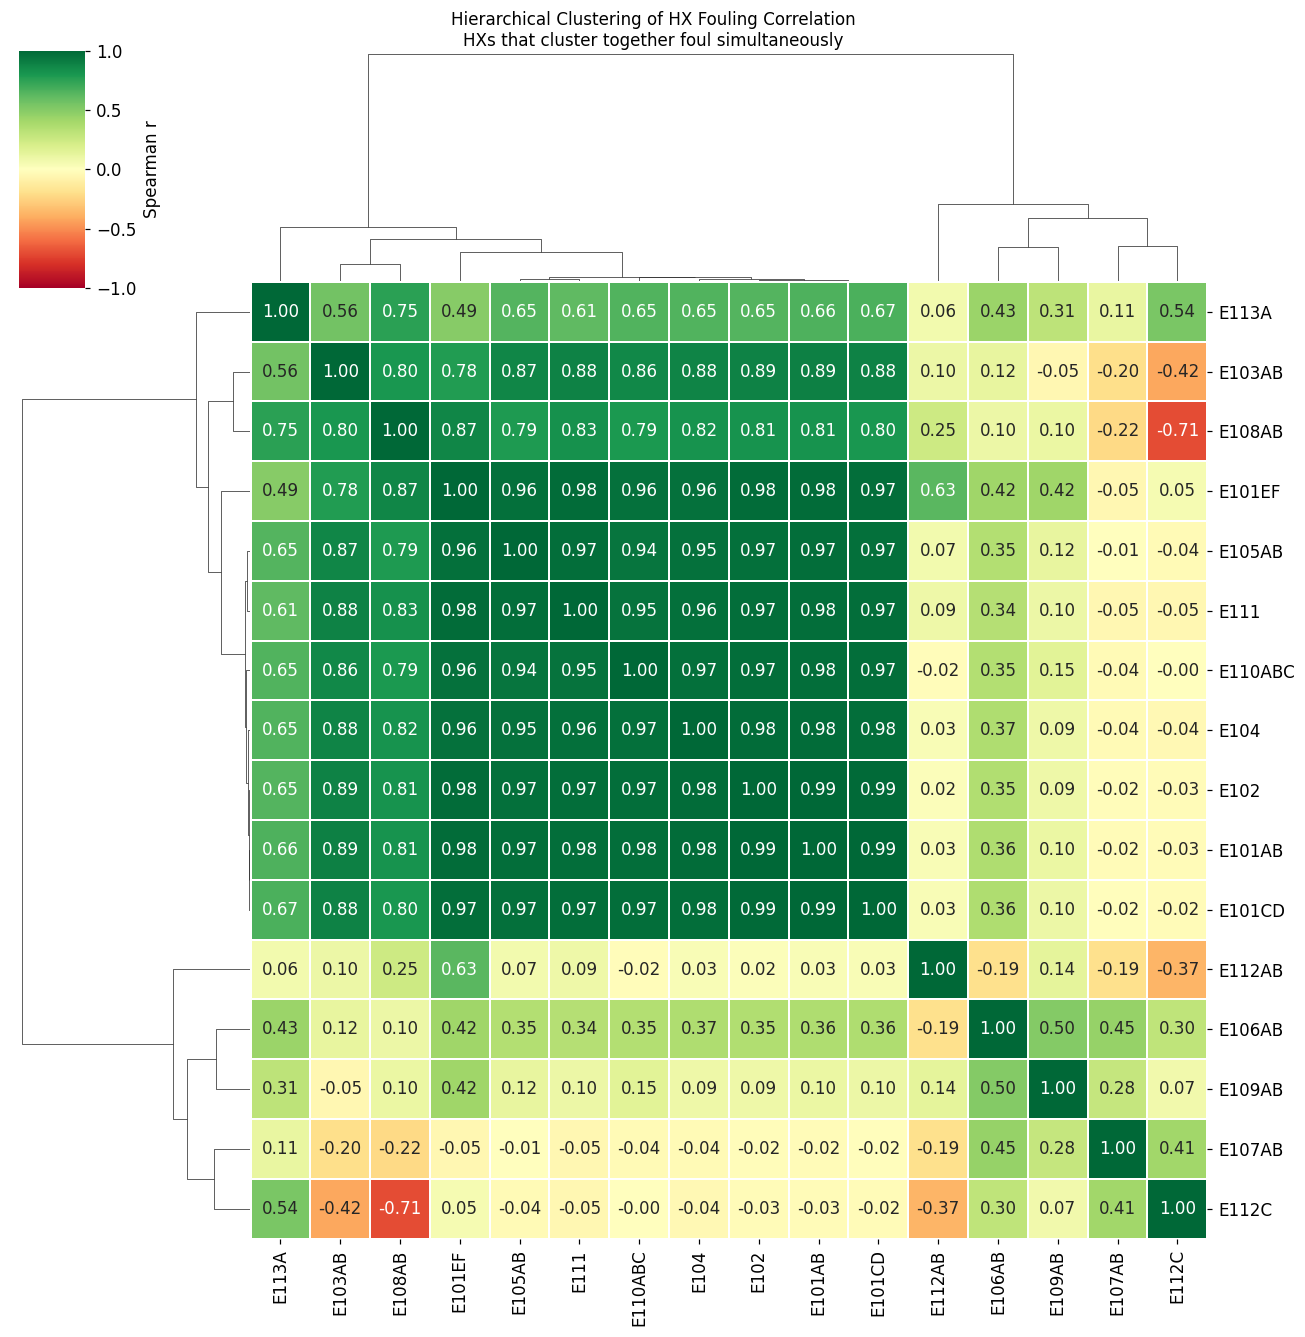

In [15]:
# ── 5b. Clustermap: which HXs foul together? ─────────────────────────────────
fig = sns.clustermap(corr_cross, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                     annot=True, fmt='.2f', linewidths=0.3,
                     figsize=(12, 12), method='ward',
                     cbar_kws={'label': 'Spearman r'})
fig.fig.suptitle('Hierarchical Clustering of HX Fouling Correlation\n'
                 'HXs that cluster together foul simultaneously', y=1.01, fontsize=11)
plt.savefig(os.path.join(FIG_DIR, '5b_clustermap.png'), bbox_inches='tight')
plt.show()

---
## 6. HX Fouling Impact on Furnace Duty

**Engineering basis:** As the preheat train fouls, less heat is recovered from hot streams.
The crude enters the furnace colder (lower CIT), so the furnace must fire harder (higher Q_furnace).

Expected relationships:
- `mean U_relative` ↓ → `Q_furnace_kW` ↑ (negative correlation)
- `mean U_relative` ↓ → CIT (`1TI116.pv`) ↓ (positive correlation)
- `sum(Q_HX)` ≈ `Q_furnace_load` (energy balance check)

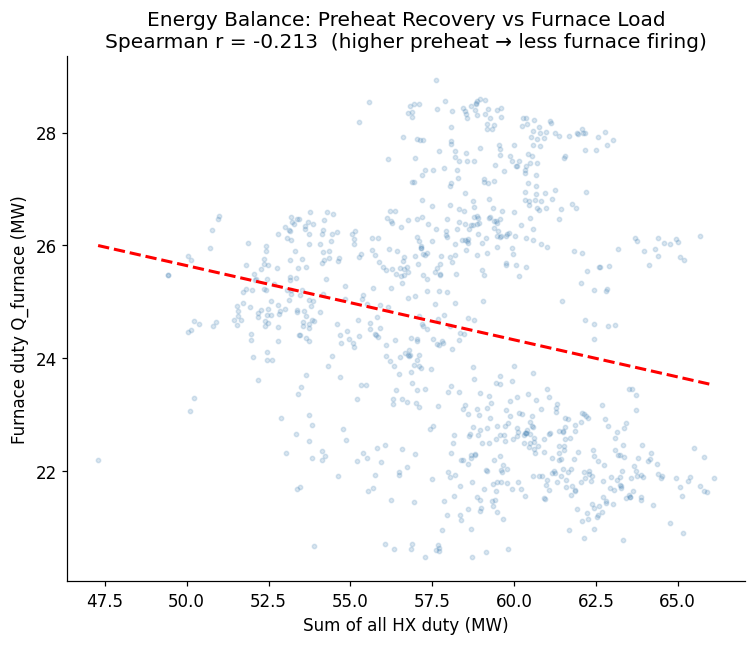

In [16]:
# ── 6a. Sum HX duty vs Q_furnace energy balance ─────────────────────────────
if Q_COLS and 'Q_furnace_kW' in feature_df.columns:
    total_hx_q = feature_df[Q_COLS].sum(axis=1)
    sub_eb = pd.DataFrame({
        'Sum_HX_Q_kW': total_hx_q,
        'Q_furnace_kW': feature_df['Q_furnace_kW']
    }).dropna()

    rho, pval = stats.spearmanr(sub_eb['Sum_HX_Q_kW'], sub_eb['Q_furnace_kW'])

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(sub_eb['Sum_HX_Q_kW']/1e3, sub_eb['Q_furnace_kW']/1e3,
               alpha=0.2, s=8, c='steelblue', rasterized=True)
    slope, intercept, *_ = stats.linregress(sub_eb['Sum_HX_Q_kW'], sub_eb['Q_furnace_kW'])
    xr = np.linspace(sub_eb['Sum_HX_Q_kW'].min(), sub_eb['Sum_HX_Q_kW'].max(), 100)
    ax.plot(xr/1e3, (slope*xr+intercept)/1e3, 'r--', lw=2)
    ax.set_xlabel('Sum of all HX duty (MW)')
    ax.set_ylabel('Furnace duty Q_furnace (MW)')
    ax.set_title(f'Energy Balance: Preheat Recovery vs Furnace Load\n'
                 f'Spearman r = {rho:.3f}  (higher preheat → less furnace firing)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '6a_energy_balance.png'), bbox_inches='tight')
    plt.show()

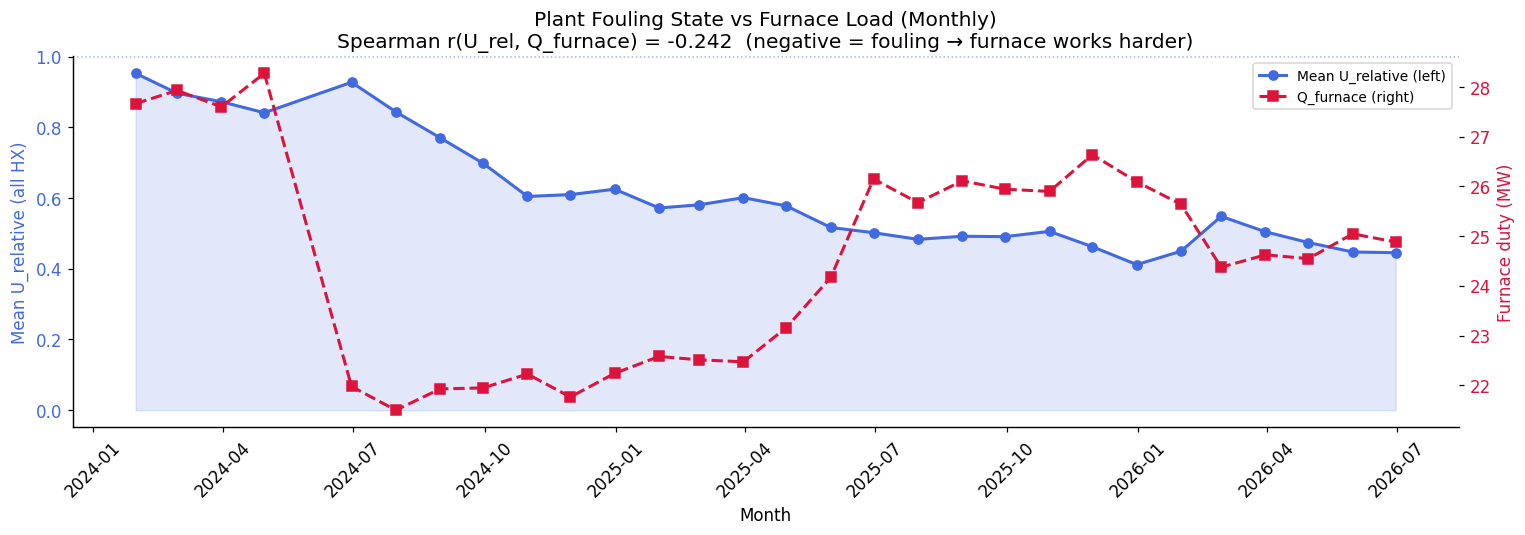

In [17]:
# ── 6b. Mean fouling state vs furnace duty (monthly) ─────────────────────────
if 'Q_furnace_kW' in feature_df.columns:
    mean_urel_daily = feature_df[UREL_COLS].mean(axis=1)
    monthly_furn = pd.DataFrame({
        'Mean_U_relative': mean_urel_daily,
        'Q_furnace_kW': feature_df['Q_furnace_kW']
    }).resample('ME').mean().dropna()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly_furn.index, monthly_furn['Mean_U_relative'], 'o-',
             color='royalblue', ms=6, lw=2, label='Mean U_relative (left)')
    ax1.fill_between(monthly_furn.index, monthly_furn['Mean_U_relative'],
                     alpha=0.15, color='royalblue')
    ax1.set_ylabel('Mean U_relative (all HX)', color='royalblue')
    ax1.tick_params(axis='y', labelcolor='royalblue')
    ax1.set_xlabel('Month')
    ax1.axhline(1.0, color='royalblue', ls=':', lw=1, alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(monthly_furn.index, monthly_furn['Q_furnace_kW']/1e3, 's--',
             color='crimson', ms=6, lw=2, label='Q_furnace (right)')
    ax2.set_ylabel('Furnace duty (MW)', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')

    rho_furn, p_furn = stats.spearmanr(monthly_furn['Mean_U_relative'],
                                        monthly_furn['Q_furnace_kW'])
    ax1.set_title(f'Plant Fouling State vs Furnace Load (Monthly)\n'
                  f'Spearman r(U_rel, Q_furnace) = {rho_furn:.3f}  '
                  f'(negative = fouling → furnace works harder)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
    ax1.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '6b_fouling_vs_furnace.png'), bbox_inches='tight')
    plt.show()

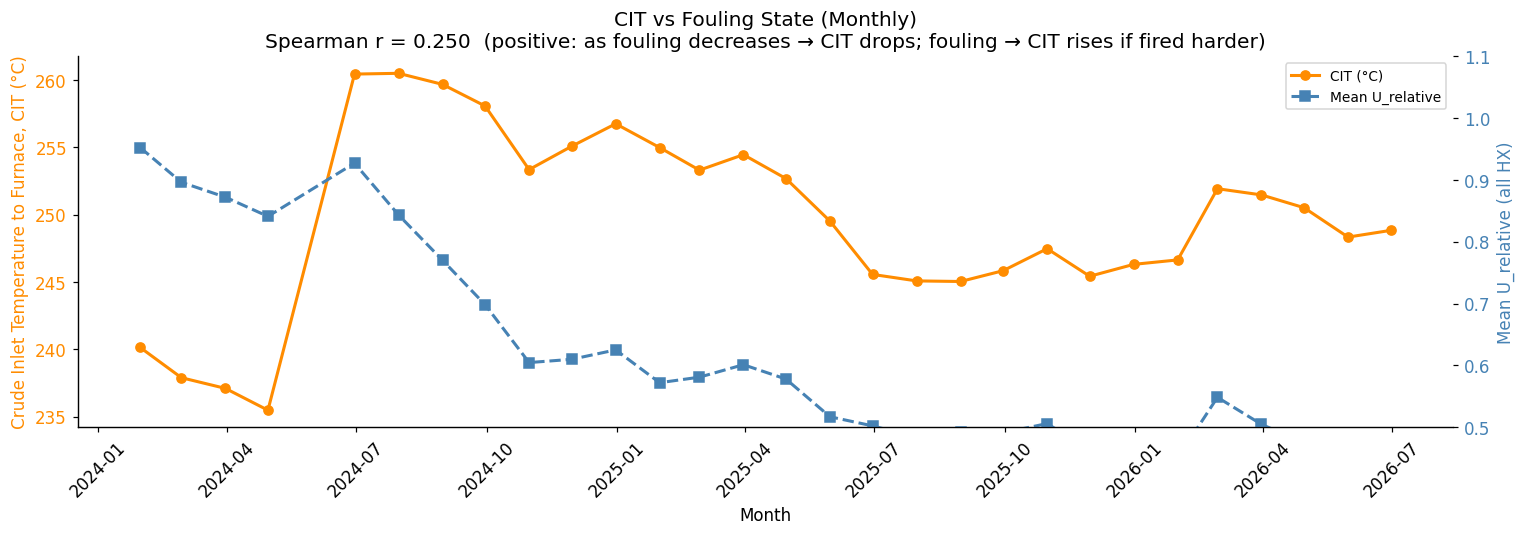

In [18]:
# ── 6c. CIT vs mean fouling state ─────────────────────────────────────────────
cit_tag = '1TI116.pv'
if cit_tag in feature_df.columns:
    monthly_cit = pd.DataFrame({
        'Mean_U_relative': mean_urel_daily,
        'CIT': feature_df[cit_tag]
    }).resample('ME').mean().dropna()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly_cit.index, monthly_cit['CIT'], 'o-',
             color='darkorange', ms=6, lw=2, label='CIT (°C)')
    ax1.set_ylabel('Crude Inlet Temperature to Furnace, CIT (°C)', color='darkorange')
    ax1.tick_params(axis='y', labelcolor='darkorange')
    ax1.set_xlabel('Month')

    ax2 = ax1.twinx()
    ax2.plot(monthly_cit.index, monthly_cit['Mean_U_relative'], 's--',
             color='steelblue', ms=6, lw=2, label='Mean U_relative')
    ax2.set_ylabel('Mean U_relative (all HX)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax2.set_ylim(0.5, 1.1)

    rho_cit, p_cit = stats.spearmanr(monthly_cit['Mean_U_relative'], monthly_cit['CIT'])
    ax1.set_title(f'CIT vs Fouling State (Monthly)\n'
                  f'Spearman r = {rho_cit:.3f}  '
                  f'(positive: as fouling decreases → CIT drops; fouling → CIT rises if fired harder)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
    ax1.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '6c_cit_vs_fouling.png'), bbox_inches='tight')
    plt.show()

---
## 7. ML Feature Importance — Correlation with U_relative

Rank all numeric features by their Spearman correlation with U_relative (pooled across all HX).
Features with `|r| > 0.2` are candidate inputs for the fouling prediction model.

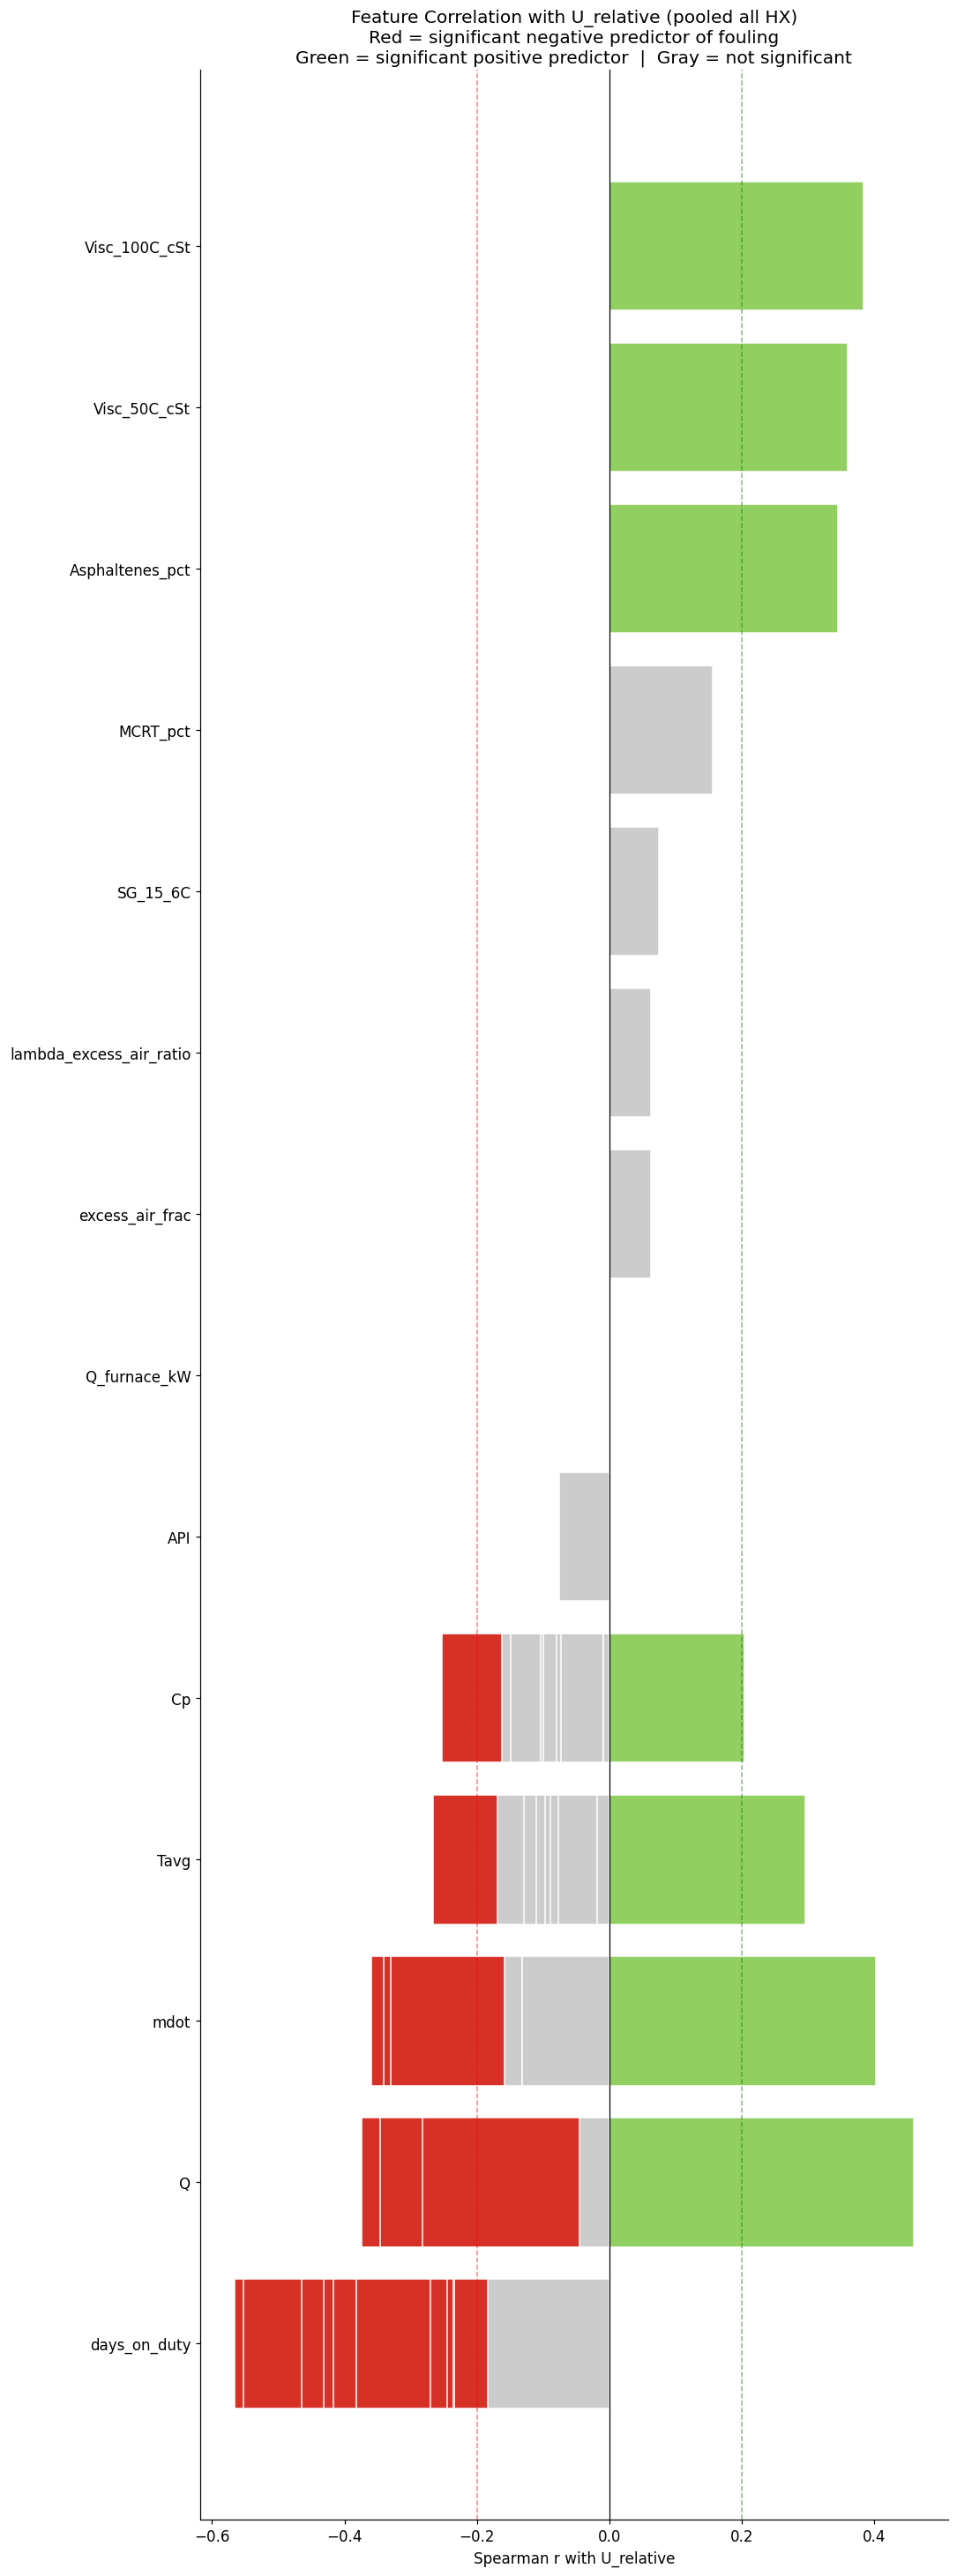


Top 10 features by |Spearman r|:
                      Spearman_r  p_value        N
E101AB_days_on_duty    -0.566516      0.0  12105.0
E101CD_days_on_duty    -0.566516      0.0  12105.0
E101EF_days_on_duty    -0.566516      0.0  12105.0
E105AB_days_on_duty    -0.566516      0.0  12105.0
E111_days_on_duty      -0.566516      0.0  12105.0
E110ABC_days_on_duty   -0.566516      0.0  12105.0
E102_days_on_duty      -0.552085      0.0  12105.0
E103AB_days_on_duty    -0.464417      0.0  12105.0
E101EF_Q                0.459510      0.0  12105.0
E112AB_days_on_duty    -0.431741      0.0  12105.0


In [19]:
# ── 7. Correlation bar chart: all features vs U_relative ─────────────────────
# Stack all HX U_relative with corresponding feature values
pool_rows = []
ml_feature_candidates = (
    [f'{h}_days_on_duty' for h in HX_LIST] +
    [f'{h}_Q' for h in HX_LIST] +
    [f'{h}_Tavg' for h in HX_LIST] +
    [f'{h}_Cp' for h in HX_LIST] +
    [f'{h}_mdot' for h in HX_LIST] +
    CRUDE_COLS +
    FURNACE_COLS
)
ml_feature_candidates = [c for c in ml_feature_candidates if c in feature_df.columns]

for hx in HX_LIST:
    uc = f'{hx}_U_relative'
    if uc not in feature_df.columns:
        continue
    # HX-specific features
    row_dict = {}
    for col in ml_feature_candidates:
        if col in feature_df.columns:
            # If col is HX-specific, match to this HX; if shared (crude/furnace), use directly
            row_dict[col] = feature_df[col]
    row_df = pd.DataFrame(row_dict)
    row_df['U_relative'] = feature_df[uc]
    row_df['HX'] = hx
    pool_rows.append(row_df)

if pool_rows:
    pool_ml = pd.concat(pool_rows, ignore_index=True)
    corr_ml = {}
    for col in ml_feature_candidates:
        if col in pool_ml.columns:
            sub = pool_ml[['U_relative', col]].dropna()
            if len(sub) >= 30:
                rho, pval = stats.spearmanr(sub[col], sub['U_relative'])
                corr_ml[col] = {'Spearman_r': rho, 'p_value': pval, 'N': len(sub)}

    corr_ml_df = pd.DataFrame(corr_ml).T.sort_values('Spearman_r')
    corr_ml_df['significant'] = corr_ml_df['p_value'] < 0.05

    # Shorten labels for display only — keep corr_ml_df.index (real column names) unique
    def shorten(col):
        for hx in HX_LIST:
            col = col.replace(hx+'_', '')
        return col

    display_labels = [shorten(c) for c in corr_ml_df.index]

    colors = ['#d73027' if (r < -0.2 and sig) else
              '#91cf60' if (r > 0.2 and sig) else '#cccccc'
              for r, sig in zip(corr_ml_df['Spearman_r'], corr_ml_df['significant'])]

    fig, ax = plt.subplots(figsize=(10, max(6, len(corr_ml_df)*0.3)))
    ax.barh(display_labels, corr_ml_df['Spearman_r'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline(-0.2, color='red', ls='--', lw=1, alpha=0.5)
    ax.axvline(0.2, color='green', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Spearman r with U_relative')
    ax.set_title('Feature Correlation with U_relative (pooled all HX)\n'
                 'Red = significant negative predictor of fouling\n'
                 'Green = significant positive predictor  |  Gray = not significant')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '7_ml_feature_corr.png'), bbox_inches='tight')
    plt.show()

    print('\nTop 10 features by |Spearman r|:')
    print(corr_ml_df.reindex(corr_ml_df['Spearman_r'].abs().sort_values(ascending=False).index)
          .head(10)[['Spearman_r','p_value','N']].to_string())

---
## 8. Summary

### Key Findings

| Question | Finding |
|---|---|
| Fouling vs. time-on-duty | Expected negative correlation; validates run segmentation |
| Crude quality drivers | Asphaltenes_pct & MCRT_pct → strongest fouling drivers |
| Temperature effect | Hotter HXs (downstream) tend to foul faster |
| Cross-HX pattern | Cluster structure reveals plant-wide vs. local fouling |
| Furnace impact | Fouling → lower CIT → furnace works harder |

### ML Feature Recommendation
- **Priority inputs:** `days_on_duty`, `Asphaltenes_pct`, `MCRT_pct`, `Tavg`, `Q`
- **Target:** `U_relative` (continuous, 0→1)
- **Per-HX model** preferred over one global model (different baseline U)

→ Next: **2_pca.ipynb** for dimensionality reduction and fouling state visualization